<a href="https://colab.research.google.com/github/joaonetto/projetoAplicado-IV/blob/main/notebook/project-ImpossibleTravel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><a href="https://nbviewer.org/github/joaonetto/projetoAplicado-IV/blob/main/notebook/project-ImpossibleTravel.ipynb" target="_parent"><img src="https://img.shields.io/badge/Open%20In%20NBView-blue?logo=javascript" alt="Open In NBViewer"/></a>

<img src="https://raw.githubusercontent.com/joaonetto/projetoAplicado-IV/refs/heads/main/Images/Mackenzie.png" width="25%" align="left"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**

---

# **Titulo do Projeto**:

### ***ChronoSec***: Detecção Comportamental e Séries Temporais para Segurança de Login (UEBA) em Eventos Google
---

**Projeto**: *Impossible Travel Detection*

---

In [1]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'João Silveira Campos Netto, 10441670'  #@param {type:"string"}
Aluno2 = 'Alex Luiz Rabelo, 10442968'  #@param {type:"string"}
Aluno3 = 'Antônio Henrique Caldas Mello, 10433799'  #@param {type:"string"}

## Introdução

Este projeto investiga a detecção de anomalias em processos de autenticação a partir de _logs_ de _login_, com ênfase na identificação de eventos classificados como **Impossible Travel**, isto é, ocorrências em que acessos sucessivos de uma mesma identidade sugerem deslocamentos geográficos incompatíveis com o intervalo de tempo transcorrido entre eles. O principal motivador da proposta reside na necessidade de aprimorar a capacidade de detecção e resposta a possíveis comprometimentos de credenciais, reutilização indevida de sessões e acessos não autorizados em ambientes corporativos distribuídos, especialmente em contextos nos quais usuários, aplicações e serviços operam de forma geograficamente dispersa. Nesse cenário, abordagens baseadas exclusivamente em regras fixas ou limiares rígidos tendem a apresentar limitações relevantes, seja pela elevada sensibilidade a imprecisões de geolocalização, seja pela dificuldade de incorporar variabilidades legítimas de comportamento. Assim, o objetivo geral do projeto consiste em modelar, de forma analítica e adaptativa, a plausibilidade espacial e temporal dos acessos de usuários, produzindo indicadores interpretáveis de risco capazes de subsidiar a priorização de eventos potencialmente críticos.

A proposta adota uma perspectiva de **séries temporais** orientadas a eventos, na qual cada autenticação é compreendida não como uma ocorrência isolada, mas como parte de uma sequência cronológica de acessos associados a uma mesma identidade. Nessa formulação, a ordem dos eventos, o intervalo de tempo entre eles e sua distribuição geográfica tornam-se elementos centrais para a análise. No domínio de segurança, o conceito de **Impossible Travel** emerge justamente da articulação entre essas dimensões, pois um par de _logins_ consecutivos pode ser examinado à luz da distância entre localidades, da duração do deslocamento implícito e da consistência desse movimento com condições minimamente plausíveis do mundo físico. Dessa forma, o projeto busca representar a normalidade de acesso por meio de trajetórias espaço-temporais, permitindo distinguir entre mobilidade legítima, variações esperadas de uso e padrões com maior potencial de indicar anomalia ou abuso de identidade.

Para viabilizar essa modelagem, o núcleo metodológico articula duas camadas complementares de análise. A primeira é determinística e fundamenta-se em cálculo geoespacial, empregando a fórmula de **Haversine** para estimar a distância entre coordenadas geográficas associadas a eventos consecutivos de autenticação. A partir dessa distância e do intervalo temporal entre acessos, calcula-se a velocidade média implícita do deslocamento, incorporando ainda fatores de correção relacionados à incerteza da geolocalização, como o raio de acurácia estimado. Essa etapa tem papel central na formalização da hipótese de **Impossible Travel**, pois traduz registros brutos de autenticação em evidências quantitativas de plausibilidade física. Em termos práticos, o mecanismo transforma pares de eventos em uma métrica objetiva de deslocamento, permitindo avaliar se a sequência observada é compatível com uma movimentação humana plausível ou se revela um padrão cuja velocidade excede limites razoáveis.

A segunda camada metodológica introduz uma dimensão comportamental e preditiva, por meio de redes neurais recorrentes do tipo **Long Short-Term Memory (LSTM)**. Nesse contexto, o modelo é treinado sobre sequências compostas por latitude, longitude e deltas temporais entre eventos, de forma a aprender regularidades associadas às trajetórias observadas no histórico. A importância da **LSTM** decorre de sua capacidade de capturar dependências temporais, preservar contexto sequencial e modelar relações não lineares entre posição geográfica e tempo transcorrido. Mesmo em janelas curtas, o modelo contribui para projetar as observações em um espaço comportamental no qual eventos coerentes com o histórico tendem a ser previstos com maior fidelidade, enquanto eventos atípicos produzem maior erro entre o valor esperado e o efetivamente observado. Nesse sentido, a rede recorrente não substitui a lógica física do **Impossible Travel**, mas a complementa, ao acrescentar uma camada de sensibilidade ao comportamento histórico e à dinâmica individual dos acessos.

A hipótese central do projeto é que eventos compatíveis com trajetórias habituais e fisicamente plausíveis tendem a apresentar, simultaneamente, velocidades coerentes e baixo erro preditivo no modelo sequencial, ao passo que acessos potencialmente anômalos revelam combinações mais discrepantes entre deslocamento geográfico, intervalo temporal e padrão histórico. Dessa forma, a velocidade implícita do deslocamento e o erro de predição comportamental são utilizados como proxies quantitativas de desvio, compondo uma estrutura analítica capaz de apoiar a triagem de eventos em um cenário predominantemente não supervisionado. A partir dessas medidas, o projeto estabelece uma lógica de pontuação contínua para classificar e priorizar ocorrências, permitindo organizar investigações, definir limiares de interesse e agregar evidências por usuário ou por trajetória. Essa estrutura contribui para a sistematização da análise e para a redução do esforço manual, ao transformar registros de autenticação em indicadores comparáveis, interpretáveis e operacionalmente acionáveis no contexto de monitoramento de segurança.

## Referêncial Teórico

A detecção de anomalias em autenticação parte do pressuposto de que eventos de _login_, quando observados em sequência, carregam informação comportamental, espacial e temporal suficiente para distinguir padrões usuais de ocorrências potencialmente maliciosas. Nesse contexto, a solução de **Impossible Travel** insere-se no campo mais amplo de **User and Entity Behavior Analytics (UEBA/UBA)**, abordagem que busca construir perfis de normalidade a partir de evidências operacionais, como horários de acesso, origem geográfica, dispositivos, aplicações e recorrência de uso. Em ambientes de identidade federada e serviços distribuídos, essa lógica tem sido empregada para resumir o comportamento do usuário em “assinaturas” ou _fingerprints_ de sessão, permitindo que desvios sejam tratados como indícios de comprometimento, uso indevido de credenciais ou abuso de acesso. Trabalhos nessa linha mostram que a modelagem do comportamento do usuário é especialmente valiosa quando a segurança não pode depender apenas de regras estáticas, pois a variabilidade legítima entre identidades tende a tornar abordagens rígidas excessivamente sensíveis a falsos positivos.

No problema específico de **Impossible Travel**, o conceito central consiste em verificar se dois eventos consecutivos de autenticação, atribuídos à mesma identidade, implicam um deslocamento geográfico incompatível com o intervalo de tempo transcorrido entre eles. Em termos práticos, compara-se a posição estimada de origem de cada evento, calcula-se a distância entre esses pontos e relaciona-se esse valor ao tempo decorrido, produzindo uma velocidade implícita de deslocamento. Se essa velocidade ultrapassa limites considerados plausíveis, o par de eventos passa a ser tratado como suspeito. Soluções comerciais de identidade e segurança já utilizam essa lógica, mas também reconhecem que o problema real é mais complexo do que uma simples regra geográfica, pois fatores como _VPN_, infraestrutura em nuvem, _NAT_, mobilidade corporativa e imprecisão de geolocalização podem produzir alertas enganosos. Por isso, mecanismos modernos de **Impossible Travel** procuram incorporar contexto adicional e aprendizagem de padrão para reduzir falsos positivos.

Do ponto de vista matemático, a base clássica para esse tipo de solução é o cálculo da distância geográfica entre duas coordenadas de latitude e longitude. Nesse cenário, a fórmula de Haversine é amplamente empregada por estimar a distância de grande círculo entre dois pontos sobre uma esfera a partir de suas coordenadas angulares. Em termos conceituais, ela parte da diferença entre latitudes e longitudes e calcula o menor arco sobre a superfície esférica entre os dois pontos, multiplicando o ângulo central obtido pelo raio médio da Terra. Sua adoção é frequente em aplicações de navegação, localização e segurança porque oferece implementação simples, custo computacional baixo e boa aproximação para muitos cenários práticos. Para um projeto de **Impossible Travel**, isso significa transformar dois **logins** com coordenadas distintas em uma distância objetiva, passível de ser combinada com o intervalo temporal entre acessos para estimar a velocidade média implícita do deslocamento.

Entretanto, embora a fórmula de **Haversine** seja adequada para protótipos e análises operacionais, ela adota uma aproximação esférica da Terra e, por isso, não é a alternativa geodésica mais precisa disponível. Em problemas que exigem maior rigor métrico, sobretudo em longas distâncias ou aplicações cartográficas de alta precisão, são comuns formulações baseadas em modelos elipsoidais, como as fórmulas de **Vincenty**, que tratam a Terra como um elipsoide e oferecem precisão muito superior. A vantagem do **Haversine**, portanto, reside na simplicidade e robustez computacional; sua limitação está no fato de que a distância calculada é aproximada. Já abordagens elipsoidais aumentam a precisão, mas introduzem maior complexidade de implementação. No contexto de autenticação, em que o objetivo não é navegação de precisão centimétrica, mas sim estimativa operacional de plausibilidade, o **Haversine** tende a ser suficiente, especialmente quando combinado com margens de tolerância e metadados de acurácia da geolocalização.

A literatura sobre detecção de anomalias em _logs_ mostra que a simples aplicação de regras fixas raramente esgota o problema. Revisões recentes indicam que os métodos empregados nesse domínio incluem abordagens estatísticas, técnicas de agrupamento, mineração de fluxo de trabalho, análise de frequência temporal e modelos profundos voltados à aprendizagem de padrões normais em sequências de eventos. A principal vantagem das estratégias baseadas em regra é a interpretabilidade imediata: no caso de **Impossible Travel**, o analista consegue explicar de maneira direta que dois _logins_ sucessivos exigiriam uma velocidade incompatível com deslocamento humano plausível. Contudo, a limitação dessas abordagens é sua sensibilidade a exceções de contexto e a dificuldade de generalizar para cenários nos quais o comportamento legítimo é altamente variável. Em contrapartida, técnicas orientadas por dados conseguem capturar regularidades implícitas e adaptar-se melhor ao histórico observado, embora normalmente exijam maior cuidado com treinamento, qualidade dos dados e explicabilidade.

Entre os trabalhos correlacionados mais influentes em modelagem sequencial de _logs_, destaca-se o **DeepLog**, que propõe o uso de redes neurais recorrentes do tipo **LSTM** para modelar _logs_ como sequências e detectar desvios em relação ao comportamento esperado. A contribuição desse trabalho foi demonstrar que eventos de _log_ não precisam ser tratados apenas como ocorrências isoladas; eles podem ser entendidos como estruturas temporais nas quais a ordem importa e a anomalia emerge do afastamento em relação ao padrão normal aprendido. Para problemas de autenticação, essa perspectiva é particularmente relevante, pois acessos sucessivos podem carregar dependências temporais e contextuais que não são capturadas apenas por regras determinísticas. A vantagem da abordagem **LSTM** está em sua capacidade de modelar dependências ao longo do tempo; sua limitação, porém, reside na necessidade de preparação adequada das sequências e na menor transparência interpretativa quando comparada a um critério físico simples, como distância e velocidade.

Em uma direção semelhante, mas com arquitetura distinta, o **LogBERT** transfere para o domínio de _logs_ a lógica de representação contextual dos _Transformers_, utilizando aprendizado autossupervisionado para capturar padrões normais e identificar desvios. Em comparação com arquiteturas recorrentes, modelos baseados em atenção tendem a representar melhor dependências contextuais distribuídas ao longo da sequência, o que pode ser vantajoso em ambientes complexos, com maior variedade de eventos e relações menos locais. Ainda assim, esses modelos costumam demandar mais recursos computacionais, maior volume de dados e _pipeline_ mais sofisticado de treinamento e inferência. Para um projeto como o de **Impossible Travel**, cuja explicabilidade operacional é relevante e cujo objetivo inclui preservar uma forte ligação entre indício analítico e plausibilidade física, a adoção de um modelo sequencial mais simples, como **LSTM**, pode representar um compromisso metodológico adequado entre capacidade de aprendizado e viabilidade de implementação.

Outra família de soluções correlatas é a dos _autoencoders_, amplamente utilizada em detecção não supervisionada de anomalias. Nessa estratégia, o modelo é treinado para reconstruir padrões normais; quando recebe um evento ou sequência fora da distribuição esperada, tende a produzir maior erro de reconstrução, que passa a funcionar como _proxy_ de desvio. Trabalhos aplicados a comportamento interno, autenticação e _logs_ de identidade mostram que _autoencoders_, inclusive com **LSTM**, são úteis quando há escassez de rótulos confiáveis de ataque e quando se deseja modelar a normalidade sem enumerar previamente todos os cenários anômalos possíveis. Em _logs_ de autenticação, essa abordagem é atraente porque credenciais comprometidas e acessos indevidos nem sempre produzem assinaturas rígidas e repetitivas; muitas vezes, o evento suspeito é justamente aquele que parece “estatisticamente estranho” em relação ao histórico do usuário. A vantagem dessa linha está em sua adequação a cenários não supervisionados; a limitação está no fato de que o erro do modelo nem sempre é imediatamente interpretável do ponto de vista operacional sem uma camada adicional de contexto.

À luz desses trabalhos, a alternativa adotada neste projeto, combinar cálculo geoespacial com modelagem sequencial comportamental, pode ser entendida como uma solução híbrida. A parte geográfica, baseada em **Haversine**, responde à pergunta física elementar: **“o deslocamento implícito entre dois logins é plausível?”**. A parte sequencial, implementada com **LSTM**, responde a uma pergunta complementar: **“mesmo que a regra geográfica sinalize risco, esse evento também se afasta do padrão histórico aprendido para a identidade ou para a trajetória observada?”**. Essa composição apresenta uma vantagem importante em relação a soluções puramente determinísticas, porque reduz a dependência de um único critério; e também apresenta uma vantagem em relação a soluções puramente comportamentais, porque preserva um eixo de interpretabilidade forte, ancorado em espaço, tempo e velocidade. Sua principal limitação continua sendo a qualidade da geolocalização por _IP_ e a necessidade de tratar contextos benignos que podem imitar **Impossible Travel**, como _VPNs_, _proxies_ corporativos e infraestruturas distribuídas, razão pela qual sistemas maduros do mercado também recorrem a filtragem contextual e aprendizado de padrão.

Em síntese, o referencial teórico do problema mostra que **Impossible Travel** não deve ser visto apenas como uma regra de distância dividida pelo tempo, mas como um caso particular de detecção de anomalias em identidade digital, situado na interseção entre **UEBA**, análise de _logs_, modelagem espaço-temporal e aprendizado de máquina. A literatura correlata sustenta que métodos baseados exclusivamente em regras oferecem clareza e rastreabilidade, mas tendem a sofrer com rigidez e falso positivo; por outro lado, métodos baseados em modelagem sequencial, _autoencoders_ e arquiteturas profundas ampliam a sensibilidade a padrões complexos, embora tragam desafios de explicabilidade e custo analítico. Nesse equilíbrio, a solução híbrida proposta mostra aderência tanto ao fundamento físico do deslocamento geográfico quanto à necessidade contemporânea de interpretar autenticações como trajetórias comportamentais, e não apenas como eventos isolados.

## Referências

MARTÍN, Alejandro G.; BELTRÁN, Marta; FERNÁNDEZ-ISABEL, Alberto; MARTÍN DE DIEGO, Isaac. An approach to detect user behaviour anomalies within identity federations. Computers & Security, v. 108, 102356, set. 2021. Disponível em: https://www.sciencedirect.com/science/article/pii/S0167404821001802. Acesso em: 1 mar. 2026.

KIM, Seo-Yi; LEE, Il-Gu. LSTM autoencoder-based insider abnormal behavior detection using de-identified data. In: INTERNATIONAL CONFERENCE ON INFORMATION SYSTEMS SECURITY AND PRIVACY, 10., 2024. Proceedings […] [S. l.]: SCITEPRESS, 2024. p. 609-620. Disponível em: https://www.scitepress.org/Papers/2024/124580/124580.pdf. Acesso em: 2 mar. 2026.

MICROSOFT. Create Defender for Cloud Apps anomaly detection policies. Microsoft Learn, [s. l.], 2025. Disponível em: https://learn.microsoft.com/en-us/defender-cloud-apps/anomaly-detection-policy. Acesso em: 27 fev. 2026.

GUO, Haixuan; YUAN, Shuhan; WU, Xintao. LogBERT: log anomaly detection via BERT. arXiv, 2021. Disponível em: https://arxiv.org/pdf/2103.04475. Acesso em: 27 fev. 2026.

DU, Min; LI, Feifei; ZHENG, Guineng; SRIKUMAR, Vivek. DeepLog: anomaly detection and diagnosis from system logs through deep learning. In: ACM SIGSAC CONFERENCE ON COMPUTER AND COMMUNICATIONS SECURITY, 24., 2017, Dallas, TX, USA. Proceedings […] New York, NY: ACM, 2017. Disponível em: https://users.cs.utah.edu/~lifeifei/papers/deeplog.pdf. Acesso em: 25 fev. 2026.

LANDAUER, Max; ONDER, Sebastian; SKOPIK, Florian; WURZENBERGER, Markus. Deep learning for anomaly detection in log data: a survey. arXiv, 2022. Disponível em: https://arxiv.org/pdf/2207.03820. Acesso em: 25 fev. 2026.

## Diagrama da Solução

<img src="https://github.com/joaonetto/projetoAplicado-IV/blob/main/Images/ImpossibleTravel.jpg?raw=true" width="100%"/>

O diagrama representa uma arquitetura em nuvem orientada à detecção de anomalias em autenticações com foco em **Impossible Travel**, concebida como um fluxo contínuo de processamento analítico que integra ingestão de eventos, enriquecimento contextual, modelagem comportamental e suporte à decisão operacional. Em vez de tratar cada autenticação como um registro isolado, a arquitetura propõe uma leitura sequencial e contextualizada dos acessos, na qual identidade, localização e tempo passam a compor uma estrutura analítica única. Essa perspectiva é particularmente relevante em ambientes corporativos distribuídos, nos quais o monitoramento de identidade depende cada vez mais da capacidade de correlacionar eventos em tempo quase real e de distinguir comportamentos legítimos de indícios de comprometimento.

Uma característica central da arquitetura é sua aderência ao paradigma de processamento contínuo de eventos, o que lhe confere escalabilidade, baixa latência e maior adequação a cenários de segurança que exigem resposta rápida. Ao operar em fluxo, a solução reduz o intervalo entre a geração do _log_ e sua avaliação analítica, permitindo que ocorrências potencialmente críticas sejam detectadas e priorizadas com maior tempestividade. Sob o ponto de vista arquitetural, essa escolha também favorece desacoplamento entre fontes de dados, motores analíticos e camadas de consumo, tornando a solução mais resiliente a variações de carga e mais compatível com ecossistemas modernos de nuvem.

Outro aspecto relevante do diagrama é a incorporação de uma camada de correlação geotemporal, responsável por transformar eventos brutos de autenticação em atributos mais expressivos para análise. Nessa etapa, o acesso deixa de ser compreendido apenas como um sucesso ou falha de _login_ e passa a ser interpretado como uma observação inserida em uma trajetória espaço-temporal. Essa transformação é fundamental para o problema de **Impossible Travel**, pois a plausibilidade de um evento depende da relação entre localidade geográfica, intervalo temporal e recorrência do comportamento observado.

A arquitetura também se destaca por adotar uma abordagem híbrida de detecção, combinando um mecanismo determinístico de plausibilidade física com uma camada de aprendizado de máquina voltada à modelagem comportamental. A dimensão determinística fornece uma base objetiva e interpretável para a análise, ao estimar a viabilidade do deslocamento entre autenticações sucessivas a partir de distância geográfica e tempo decorrido. Esse componente é particularmente importante porque sustenta o alerta em critérios físicos verificáveis, o que favorece transparência analítica e facilita a comunicação do risco em contextos operacionais. Em paralelo, a camada baseada em LSTM Autoencoder acrescenta profundidade ao modelo ao aprender regularidades históricas e identificar desvios em relação ao padrão recorrente do usuário. Essa combinação permite que a solução não dependa exclusivamente de limiares fixos nem exclusivamente de inferências probabilísticas, mas articule ambas as perspectivas de forma complementar.

Do ponto de vista metodológico, a presença do _autoencoder_ recorrente reforça o caráter não supervisionado da proposta. Em cenários de segurança, essa escolha é especialmente pertinente, uma vez que eventos maliciosos rotulados são escassos, heterogêneos e nem sempre representam adequadamente a diversidade de anomalias possíveis. Ao aprender a reconstruir trajetórias e padrões de acesso considerados normais, o modelo passa a utilizar o erro de reconstrução como medida de desvio, criando uma base quantitativa para avaliar a aderência de cada nova autenticação ao comportamento histórico. Assim, a arquitetura transcende o uso de regras estáticas e passa a operar com uma noção adaptativa de normalidade, o que tende a reduzir sensibilidade excessiva a variações legítimas e a melhorar a priorização de eventos realmente relevantes.

Outro elemento de destaque é a existência de uma camada de pontuação de anomalia, responsável por consolidar evidências heterogêneas em um único escore de risco. Essa etapa é importante porque problemas reais de autenticação raramente podem ser explicados por uma única variável. A fusão entre indicadores físicos, sinais comportamentais e contexto histórico permite uma avaliação mais robusta e menos sujeita a decisões binárias simplificadas. Em termos acadêmicos, trata-se de uma estratégia de integração de evidências que amplia a capacidade discriminativa da solução e favorece sua aplicação prática em ambientes de monitoramento contínuo.

A arquitetura também evidencia a importância da persistência histórica de perfis e eventos, aspecto indispensável para qualquer solução de **UBA**. A manutenção de um repositório de histórico não serve apenas ao armazenamento, mas constitui a base para aprendizagem, reprocessamento, comparação longitudinal e contextualização das inferências em tempo real. Em outras palavras, o sistema depende de memória histórica para transformar observações pontuais em trajetórias interpretáveis. Essa característica desloca a análise de uma lógica puramente reativa para uma lógica de acompanhamento comportamental contínuo, mais coerente com os desafios contemporâneos de segurança baseada em identidade.

Por fim, o diagrama revela uma preocupação explícita com a operacionalização da análise, ao conectar o _pipeline_ analítico ao contexto do **Security Operations Center (SOC)**. Essa integração demonstra que a solução não foi concebida apenas como exercício analítico, mas como mecanismo de apoio à triagem, investigação e resposta. A geração de alertas priorizados, acompanhados de contexto suficiente para interpretação, é um aspecto decisivo para que o modelo tenha utilidade prática. Em segurança, a qualidade de uma arquitetura não depende apenas da sofisticação do algoritmo, mas também de sua capacidade de converter resultados computacionais em sinais acionáveis para o analista.

# ChronoSec — Impossible Travel

### Observações Iniciais:

⚡️ **Otimizado para Apple Silicon (M1/M2/M3)**: Este código inclui validações de hardware e arquitetura otimizada para aproveitar a aceleração de GPU via API Metal.

### Lógica do Modelo

Este notebook identifica acessos suspeitos baseados na lógica de **viagem impossível** e utiliza **Redes Neurais Recorrentes (LSTM)** para modelar comportamentos de geolocalização, aproveitando a aceleração de hardware **Apple Silicon (M2)**.

# Detecção de Impossible Travel em Logs de Acesso

Este notebook identifica acessos suspeitos baseados na lógica de **viagem impossível** e utiliza **Redes Neurais Recorrentes (LSTM)** para modelar comportamentos de geolocalização, aproveitando a aceleração de hardware **Apple Silicon (M2)**.

### Estrutura do Projeto:
1. **Configuração de Ambiente**: Verificação de suporte a GPU (Metal).
2. **Detecção Determinística**: Baseada em velocidade física (Haversine).
3. **Modelagem Comportamental Global (LSTM)**: Treinamento com contexto de geolocalização e tempo.
4. **Visualização de Performance**: Gráfico de Perda (Loss) vs Validação.
5. **Apresentação de Casos**: Cruzamento de dados físicos e comportamentais.

### Inicialização

Processo de carga de bibliotecas e variáveis de ambiente

In [2]:
#
# Bibliotecas
#
import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import warnings

from datetime import datetime, timedelta
from IPython.display import display, HTML
from math import radians, cos, sin, asin, sqrt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

warnings.filterwarnings('ignore')

In [3]:
#
# Variáveis de ambiente
#
FILENAME = "saida_enriquecida.csv"
SEP = ","
INPUT_CSV = str()
SEQ_LENGTH = 1
PATH = list()

#
# Ajuste Pandas
#
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

#
# Check se ambiente é COLAB e ajusta PATH
#
try:
    from google.colab import drive
    drive.mount('/content/drive')
    INPUT_CSV = "/"
    PATH = [
        "content",
        "drive",
        "MyDrive",
        "Mackenzie",
        "5o Semestre",
        "PA4 - Projeto Aplicado - IV",
        "Code",
        "projetoAplicado-IV",
        "Data"
    ]
except Exception:
    INPUT_CSV = ""
    PATH = [
        "..",
        "Data"
    ]


for p in PATH:
    INPUT_CSV += p + "/"

INPUT_CSV += FILENAME

### Verificação de Disponibilidade de Aceleração por GPU

Abaixo o código realiza uma verificação do ambiente computacional com o objetivo de identificar a disponibilidade de **GPU** reconhecida pelo **TensorFlow**. Inicialmente, é exibida a versão da biblioteca utilizada, favorecendo a documentação do ambiente de execução. Em seguida, o código consulta os dispositivos físicos do tipo **GPU** disponíveis no sistema. Quando uma **GPU** é detectada, o treinamento do modelo pode ser executado com aceleração por _hardware_, potencialmente reduzindo o custo computacional do processamento. Na ausência de **GPU** compatível, o treinamento ocorre na **CPU**. Em sistemas _macOS_ com **Apple Silicon**, a detecção da **GPU** depende da configuração adequada do **TensorFlow** com os pacotes _tensorflow-macos_ e _tensorflow-metal_.

In [4]:
print("Versão do TensorFlow:", tf.__version__)
dispositivos_gpu = tf.config.list_physical_devices('GPU')

if dispositivos_gpu:
    print("\n✅ GPU detectada! O treinamento será acelerado pelo seu chip M2.")
    for gpu in dispositivos_gpu:
        print("Detalhes do hardware:", gpu)
else:
    print("\n⚠️ Nenhuma GPU detectada. O treinamento ocorrerá na CPU.")
    print("Dica para Mac M1/M2: Execute no terminal 'pip install tensorflow-macos tensorflow-metal'")

Versão do TensorFlow: 2.16.2

✅ GPU detectada! O treinamento será acelerado pelo seu chip M2.
Detalhes do hardware: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Pré-processamento de Logs de Autenticação para Análise Comportamental de Acessos

O trecho de código apresenta uma etapa inicial de preparação e saneamento de dados voltada à análise de _logs_ de autenticação. Em termos metodológicos, o processo começa com o carregamento da base original em formato **CSV** e, em seguida, aplica um filtro que preserva exclusivamente eventos de autenticação bem-sucedida, representados pela categoria _login_success_. Essa decisão é coerente com cenários de modelagem comportamental, pois restringe a análise aos acessos efetivamente realizados, evitando que falhas de autenticação introduzam ruído indevido na construção do perfil de uso dos usuários.

Na sequência, o código elimina usuários que possuem apenas um único registro de _login_. Esse critério é relevante do ponto de vista analítico, uma vez que perfis comportamentais não podem ser adequadamente inferidos a partir de uma única observação temporal. Depois disso, realiza-se uma redução dimensional do conjunto de dados, mantendo apenas atributos considerados essenciais para o problema, como data do evento, identificação do usuário, tipo de evento, coordenadas geográficas, raio de precisão, cidade e descrição textual. Essa seleção contribui para simplificar o processamento e concentrar a análise em variáveis diretamente úteis para estudos espaço-temporais e comportamentais.

Posteriormente, o código converte a coluna de data para o tipo temporal apropriado, criando a variável _ts_, o que viabiliza ordenações cronológicas, cálculos de intervalos entre eventos e futuras análises de sequência. Por fim, os registros são ordenados por usuário e por instante de tempo, resultando em uma base estruturada para investigações de padrões de acesso, mobilidade e comportamento recorrente de autenticação.

In [5]:
# Carregando os dados originais
print('Carregando os dados...')
df_base = pd.read_csv(INPUT_CSV, sep=SEP)

# REGRA DE SEGURANÇA: Filtrando apenas logs de acesso bem sucedido.
df_base = df_base[df_base['Evento'] == 'login_success'].copy()

# Retira Usuários com apenas um único login
df_base['user_count'] = df_base.groupby('Usuário')['Usuário'].transform('count')
df_base = df_base[df_base['user_count'] > 1]

# Executa Cleanup de colunas desnecessárias
cols_essenciais = ['Data', 'Usuário', 'Evento', 'latitude', 'longitude', 'accuracy_radius_km', 'cidade', 'Descrição']
df_base = df_base[cols_essenciais]

# Adiciona coluna para o formato de data
df_base['ts'] = pd.to_datetime(df_base['Data'])

# Ordena por Usuário e Data (TS)
df_success = df_base.sort_values(by=['Usuário', 'ts']).copy()

print(f"Base preparada com {len(df_success)} registros de login.")

Carregando os dados...
Base preparada com 388577 registros de login.


### Cálculo da Distância Geodésica entre Dois Pontos por meio da Fórmula de Haversine

A função apresentada implementa a fórmula de **Haversine**, amplamente utilizada para estimar a distância entre dois pontos sobre a superfície terrestre a partir de suas coordenadas geográficas de latitude e longitude. Trata-se de uma abordagem clássica em problemas de geolocalização, mobilidade e análise espaço-temporal, pois considera a curvatura da Terra e produz uma aproximação adequada da distância em linha ortodrômica, isto é, a menor distância sobre a superfície esférica entre dois pontos.

Do ponto de vista computacional, a função recebe como entrada os valores de longitude e latitude de dois locais distintos. Inicialmente, essas coordenadas são convertidas de graus para radianos, uma vez que as funções trigonométricas utilizadas no cálculo operam nesse sistema angular. Em seguida, são calculadas as diferenças angulares de longitude e latitude entre os dois pontos. A partir dessas diferenças, a fórmula de **Haversine** determina um valor intermediário que representa a separação angular entre as posições observadas. Por fim, esse valor é transformado em distância linear ao ser multiplicado pelo raio médio da Terra, aqui adotado como **6371 km**.

$$
d = 2R \cdot \arcsin\left(\sqrt{\sin^2\left(\frac{\phi_2 - \phi_1}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\lambda_2 - \lambda_1}{2}\right)}\right)
$$

Sob uma perspectiva analítica, essa função é particularmente relevante em cenários de detecção de anomalias em autenticação, como no caso de **Impossible Travel**, em que se busca verificar se dois acessos sucessivos atribuídos ao mesmo usuário ocorreram em locais geograficamente distantes em um intervalo de tempo incompatível com deslocamento humano plausível. Assim, a distância calculada pela fórmula de **Haversine** constitui um elemento fundamental para a derivação de métricas de velocidade, coerência espacial e risco comportamental.

In [6]:
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * 6371

### Cálculo Seguro de Deslocamento entre Logins Consecutivos

A função _calculate_travel_safe_ calcula, de forma segura, métricas de deslocamento entre dois _logins_ consecutivos de um mesmo usuário. Ela verifica primeiro se existe um evento anterior; caso não exista, retorna zeros, pois não há base comparativa para medir distância, tempo ou velocidade.

Quando há um _login_ anterior, a função utiliza a fórmula de **Haversine** para estimar a distância geográfica entre os dois pontos. Em seguida, ajusta essa distância considerando o raio de imprecisão das localizações atual e anterior, gerando uma distância mínima mais conservadora. Depois, calcula o intervalo de tempo entre os eventos em segundos e em horas e, com isso, estima a velocidade de deslocamento. Para evitar erros computacionais, a função também impede divisão por zero quando os dois eventos ocorrem no mesmo instante.

In [7]:
def calculate_travel_safe(row):
    # Se prev_lat é nulo, é o primeiro login do usuário na série histórica.
    # Logo, distância, tempo e velocidade de deslocamento anterior são zero.
    if pd.isna(row['prev_lat']):
        return pd.Series([0.0, 0.0, 0.0, 0.0, 0.0])

    dist = haversine(row['longitude'], row['latitude'], row['prev_lon'], row['prev_lat'])

    # Tratamento de segurança caso o accuracy anterior seja nulo
    prev_acc = row['prev_accuracy'] if not pd.isna(row['prev_accuracy']) else 0.0
    min_dist = max(0, dist - (row['accuracy_radius_km'] + prev_acc))

    diff_seconds = (row['ts'] - row['prev_data']).total_seconds()
    hours = diff_seconds / 3600.0

    # Previne divisão por zero se logins ocorrerem no exato mesmo segundo
    speed = min_dist / hours if hours > 0 else 0.0

    return pd.Series([dist, min_dist, hours, speed, diff_seconds])

### Engenharia de Atributos Temporais e Espaço-Temporais para Análise de Autenticações

O trecho de código realiza uma etapa de engenharia de atributos voltada à análise comportamental de autenticações. Inicialmente, são criadas variáveis defasadas por usuário, por meio da operação groupby(...).shift(1), permitindo associar cada _login_ ao evento imediatamente anterior do mesmo indivíduo. Com isso, o conjunto passa a incorporar informações históricas relevantes, como _timestamp_ anterior, coordenadas geográficas, cidade e raio de precisão, o que viabiliza comparações sequenciais entre acessos consecutivos.

Em seguida, o código modela a variável temporal sob uma perspectiva cíclica. A hora do evento é convertida para formato decimal e depois transformada em componentes _seno_ e _cosseno_. Esse procedimento é metodologicamente importante porque preserva a natureza circular do tempo ao longo das 24 horas, evitando interpretações lineares inadequadas entre horários próximos, como 23h e 0h, que são distantes numericamente, mas adjacentes no ciclo diário.

In [8]:
df_success['prev_data'] = df_success.groupby('Usuário')['ts'].shift(1)
df_success['prev_lat'] = df_success.groupby('Usuário')['latitude'].shift(1)
df_success['prev_lon'] = df_success.groupby('Usuário')['longitude'].shift(1)
df_success['prev_cidade'] = df_success.groupby('Usuário')['cidade'].shift(1)
df_success['prev_accuracy'] = df_success.groupby('Usuário')['accuracy_radius_km'].shift(1)

# Feature de Tempo Cíclico (Seno e Cosseno da hora do dia)
df_success['hora_decimal'] = df_success['ts'].dt.hour + (df_success['ts'].dt.minute / 60.0)
df_success['hora_sin'] = np.sin(2 * np.pi * df_success['hora_decimal'] / 24.0)
df_success['hora_cos'] = np.cos(2 * np.pi * df_success['hora_decimal'] / 24.0)

df_success[['dist_km', 'min_dist_km', 'time_diff_hours', 'speed_kmh', 'time_delta_sec']] = df_success.apply(calculate_travel_safe, axis=1)

### Construção de Sequências Globais para Modelagem Preditiva de Comportamento de Login

O código apresentado implementa uma função de preparação de dados sequenciais para treinamento de modelos preditivos, especialmente adequada a abordagens de séries temporais e aprendizado sequencial. Seu objetivo central é transformar registros históricos de autenticação em janelas temporais deslizantes, permitindo que o modelo aprenda padrões de comportamento a partir da evolução recente dos eventos de cada usuário.

Inicialmente, a função seleciona um conjunto de variáveis relevantes para a modelagem, incluindo atributos espaciais, temporais e cinemáticos, como latitude, longitude, diferença de tempo entre eventos, distância percorrida, velocidade estimada e representação cíclica do horário por _seno_ e _cosseno_. Em seguida, essas variáveis são normalizadas com o **MinMaxScaler**, procedimento importante para reduzir diferenças de escala entre atributos e favorecer a estabilidade do treinamento de modelos de aprendizado de máquina.

Na etapa seguinte, os dados são agrupados por usuário, preservando a individualidade do comportamento de autenticação. Para cada usuário com histórico suficiente, a função aplica uma estratégia de janela deslizante (sliding window), na qual sequências consecutivas de tamanho _n_steps_ são utilizadas como variáveis de entrada **X**. O alvo preditivo **y**, por sua vez, corresponde às coordenadas geográficas normalizadas do próximo evento, isto é, latitude e longitude do passo subsequente. Dessa forma, o modelo passa a aprender a relação entre a trajetória recente de um usuário e a estimativa de sua próxima localização de acesso.

Além das sequências de entrada e saída, a função também armazena os índices originais dos registros correspondentes ao alvo, o que facilita a posterior reconciliação entre previsões e eventos reais no conjunto de dados. Em síntese, trata-se de uma rotina de engenharia de dados sequenciais que converte _logs_ brutos em estruturas adequadas para modelos preditivos de mobilidade ou comportamento de autenticação, sendo particularmente útil em contextos de detecção de anomalias, previsão de localização e análise de padrões espaço-temporais.

In [9]:
def build_global_sequences(df, n_steps=3):
    X_global, y_global, indices = [], [], []
    scaler = MinMaxScaler()

    # Ampliamos as features para incluir a cinemática calculada
    features_to_scale = [
        'latitude',
        'longitude',
        'time_delta_sec',
        'dist_km',  # Nova feature preditiva
        'speed_kmh',  # Nova feature preditiva,
        'hora_sin',
        'hora_cos'
    ]

    # Criamos nomes dinâmicos para as colunas escaladas
    scaled_cols = [f"{col}_s" for col in features_to_scale]

    # Normalização de todas as variáveis selecionadas
    df.loc[:, scaled_cols] = scaler.fit_transform(df[features_to_scale])

    for user, group in df.groupby('Usuário'):
        # Verifica se o usuário tem histórico suficiente para a janela + 1 target
        if len(group) > n_steps:
            user_data = group[scaled_cols].values
            idx_list = group.index.tolist()

            # Movimentação da Janela Deslizante (Sliding Window)
            for i in range(len(user_data) - n_steps):
                # X: O histórico de 'n_steps' contendo TODAS as 5 features
                X_global.append(user_data[i: i + n_steps])

                # y: O que queremos prever no próximo passo.
                # O índice :2 pega apenas 'latitude_s' e 'longitude_s'.
                y_global.append(user_data[i + n_steps, :2])

                indices.append(idx_list[i + n_steps])

    return np.array(X_global), np.array(y_global), scaler, indices

### Preparação do Conjunto de Dados para Treinamento de Rede LSTM

Abaixo o código realiza a etapa de configuração e preparação do conjunto de dados para treinamento de um modelo sequencial do tipo **LSTM**. Inicialmente, define-se o tamanho da janela temporal por meio da variável **N_STEPS = 3**, indicando que cada amostra de entrada será composta pelos três eventos anteriores de autenticação de um mesmo usuário. Em seguida, a função _build_global_sequences_ é chamada para transformar a base processada em estruturas adequadas ao aprendizado supervisionado, produzindo as entradas _X_train_, os alvos _y_train_, o objeto de normalização _master_scaler_ e os índices dos registros associados aos valores alvo.

Do ponto de vista metodológico, essa etapa converte dados tabulares em tensores sequenciais, compatíveis com arquiteturas recorrentes utilizadas em modelagem temporal. O conjunto _X_train_ assume a forma tridimensional exigida por redes **LSTM**, isto é, organizada em amostras, janela de tempo e atributos, enquanto _y_train_ contém os valores de saída a serem previstos, neste caso correspondentes às coordenadas geográficas futuras.

In [10]:
N_STEPS = 3
X_train, y_train, master_scaler, target_indices = build_global_sequences(df_success, n_steps=N_STEPS)

print(f"Dataset pronto para a LSTM!")
print(f"Dataset pronto para GPU: {X_train.shape}")
print(f"Formato de X_train: {X_train.shape} -> (Amostras, Janela de Tempo, Features)")
print(f"Formato de y_train: {y_train.shape} -> (Amostras, Targets [Lat, Lon])")

Dataset pronto para a LSTM!
Dataset pronto para GPU: (374017, 3, 7)
Formato de X_train: (374017, 3, 7) -> (Amostras, Janela de Tempo, Features)
Formato de y_train: (374017, 2) -> (Amostras, Targets [Lat, Lon])


### Treinamento de Rede LSTM para Predição Espaço-Temporal e Cálculo de Score Comportamental

Nesta fase é implementada a etapa de treinamento de um modelo sequencial baseado em **LSTM** para aprendizagem de padrões espaço-temporais de autenticação. Inicialmente, a execução é condicionada à existência de amostras válidas em _X_train_, evitando o treinamento sobre conjuntos vazios. Em seguida, as dimensões da entrada são obtidas dinamicamente a partir do próprio tensor de treinamento, o que torna o procedimento mais robusto e reduz dependência de valores fixos previamente codificados.

A arquitetura definida é composta por duas camadas **LSTM** empilhadas, com **128** e **64** unidades, intercaladas por camadas de **Dropout**. Essa estrutura permite capturar dependências temporais presentes nas sequências de _login_, ao mesmo tempo em que busca reduzir o risco de sobreajuste. A camada de saída _Dense(2)_ indica que o modelo foi construído para prever duas variáveis contínuas, correspondentes às coordenadas geográficas futuras de latitude e longitude. O processo de treinamento utiliza o otimizador **Adam** e a função de perda **MSE (Mean Squared Error)**, adequada para problemas de regressão.

Um aspecto metodologicamente relevante é o uso do mecanismo de **EarlyStopping**, que monitora a perda de validação e interrompe o treinamento quando não há melhora após determinado número de épocas. Essa estratégia contribui para maior eficiência computacional e melhor generalização do modelo, preservando automaticamente os melhores pesos obtidos. O gráfico gerado ao final permite acompanhar visualmente a evolução do erro em treino e validação, oferecendo uma forma de diagnóstico do comportamento do aprendizado.

Após o treinamento, o código realiza predições sobre o conjunto de entrada e calcula o erro entre o valor previsto e o valor real. Esse erro é obtido pela norma Euclidiana entre os vetores predito e observado no espaço normalizado, produzindo uma medida contínua de desvio comportamental. Em termos analíticos, tal medida pode ser interpretada como um _score_ comportamental, isto é, um indicador quantitativo do quanto o comportamento real de _login_ diverge do padrão aprendido pelo modelo. Por fim, esse _score_ é incorporado ao _DataFrame_ original, permitindo associar cada evento a um valor numérico útil para tarefas posteriores de detecção de anomalias, priorização investigativa e apoio à análise comportamental de usuários.

2026-03-07 11:52:15.364131: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-03-07 11:52:15.364165: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-03-07 11:52:15.364172: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-03-07 11:52:15.364189: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-07 11:52:15.364198: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



--- Iniciando Treinamento Global Acelerado ---

Epoch 1/40


2026-03-07 11:52:16.380229: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


4676/4676 ━━━━━━━━━━━━━━━━━━━━ 57s 12ms/step - loss: 5.7571e-04 - val_loss: 3.0307e-04
Epoch 2/40
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 54s 12ms/step - loss: 2.6840e-04 - val_loss: 3.0694e-04
Epoch 3/40
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 54s 12ms/step - loss: 2.5842e-04 - val_loss: 2.6788e-04
Epoch 4/40
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 54s 12ms/step - loss: 2.5711e-04 - val_loss: 2.9649e-04
Epoch 5/40
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 54s 12ms/step - loss: 2.5168e-04 - val_loss: 2.7476e-04
Epoch 6/40
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 54s 12ms/step - loss: 2.5336e-04 - val_loss: 3.1406e-04
Epoch 7/40
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 54s 12ms/step - loss: 2.4852e-04 - val_loss: 2.6722e-04
Epoch 8/40
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 54s 12ms/step - loss: 2.4592e-04 - val_loss: 2.6884e-04
Epoch 9/40
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 54s 12ms/step - loss: 2.4449e-04 - val_loss: 3.0906e-04
Epoch 10/40
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 54s 12ms/step - loss: 2.4259e-04 - val_loss: 2.8328e-04
Epoch 11/40
4676/4676 ━━━━━━━━

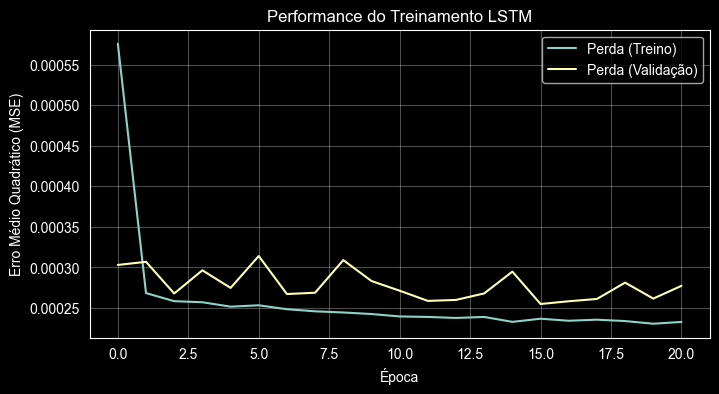

11689/11689 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step

Score comportamental calculado e integrado ao dataframe com sucesso!


In [11]:
if X_train.shape[0] > 0:
    # 1. Captura dinâmica das dimensões para evitar hardcoding
    janela_tempo = X_train.shape[1] # Corresponde ao N_STEPS (3)
    num_features = X_train.shape[2] # Agora reconhecerá 5 automaticamente

    model = Sequential([
        LSTM(128, activation='tanh', input_shape=(janela_tempo, num_features), return_sequences=True),
        Dropout(0.2), # Melhoria: Adicionado para evitar overfitting na transição final
        LSTM(64, activation='tanh'),
        Dropout(0.2),
        Dense(2)      # Saída esperada: [Latitude, Longitude]
    ])

    model.compile(optimizer='adam', loss='mse')

    # Parada inteligente do treinamento
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,               # Espera 5 épocas sem melhora antes de parar
        restore_best_weights=True
    )

    print("\n--- Iniciando Treinamento Global Acelerado ---\n")
    history = model.fit(
        X_train,
        y_train,
        epochs=40,
        batch_size=64,
        verbose=1,
        validation_split=0.2,
        callbacks=[early_stop]  # Aplicação do callback
    )

    # --- GRÁFICO DE PERFORMANCE DE TREINAMENTO ---
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Perda (Treino)')
    plt.plot(history.history['val_loss'], label='Perda (Validação)')
    plt.title('Performance do Treinamento LSTM')
    plt.xlabel('Época')
    plt.ylabel('Erro Médio Quadrático (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- CÁLCULO DO ERRO COMPORTAMENTAL ---
    y_pred = model.predict(X_train)
    # A norma do vetor nos dá a distância Euclidiana entre a predição e o real (nas escalas normalizadas)
    errors = np.linalg.norm(y_train - y_pred, axis=1)

    # 2. Correção: Gravando os resultados no DataFrame
    df_success['score_comportamental'] = 0.0
    for i, idx in enumerate(target_indices):
        if idx in df_success.index:
            df_success.at[idx, 'score_comportamental'] = float(errors[i])

    print("\nScore comportamental calculado e integrado ao dataframe com sucesso!")

### Função de Conversão de Tempo Decimal para Formato Cronológico

A função _format_timedelta_ converte valores de tempo expressos em horas decimais para o formato **HH:MM:SS**. Inicialmente, trata valores ausentes, retornando 00:00:00 como padrão. Em seguida, transforma o valor em uma duração temporal e o decompõe em horas, minutos e segundos.

In [12]:
# Função auxiliar para formatar horas decimais em HH:MM:SS
def format_timedelta(hours_decimal):
    if pd.isna(hours_decimal):
        return "00:00:00"
    td = timedelta(hours=hours_decimal)
    total_seconds = int(td.total_seconds())
    hours, remainder = divmod(total_seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"

### Recuperação da Descrição do Evento Anterior

O código abaixo garante a existência da variável _prev_descricao_ no conjunto de dados. Para isso, verifica inicialmente se a coluna já está presente no DataFrame. Caso não exista, ela é criada a partir do deslocamento da coluna _Descrição_ dentro de cada grupo de usuário, associando a cada registro a descrição textual do evento imediatamente anterior.

In [13]:
# Garantindo que temos a descrição do log anterior
if 'prev_descricao' not in df_success.columns:
    df_success['prev_descricao'] = df_success.groupby('Usuário')['Descrição'].shift(1)

### Apresentação Interpretativa de Casos de Autenticação com Apoio Visual e Classificação Comportamental

A função _apresentar_estudo_caso_ tem como objetivo exibir  casos selecionados de autenticação de forma interpretável e visualmente estruturada. Inicialmente, ela verifica se o subconjunto de dados está vazio. Caso existam registros, a função seleciona os primeiros casos do conjunto, assumindo que já estejam ordenados conforme a regra analítica definida.

Para cada caso, são exibidas informações comparativas entre o evento de origem e o evento de destino, incluindo horário, cidade e descrição textual do _log_. Em seguida, a função apresenta métricas derivadas, como distância geográfica, diferença temporal e velocidade média estimada, complementadas pelo _score_comportamental_ produzido pelo modelo **LSTM**. Esse _score_ é interpretado com base em limiares, classificando cada caso em níveis de normalidade, alerta ou criticidade.

Adicionalmente, a função gera uma visualização geográfica em mapa interativo, representando os pontos de origem e destino e a trajetória entre eles. Por fim, disponibiliza um link externo para abertura da rota no **Google Maps**.

In [14]:
def apresentar_estudo_caso(df_subset, limiar_critico, limiar_alerta, titulo, cor_mapa, n_casos=3):
    display(HTML(f"<h2 style='color:{cor_mapa}; border-bottom: 2px solid {cor_mapa}; font-family: sans-serif; padding-bottom: 5px; margin-top: 30px;'>{titulo}</h2>"))

    if df_subset.empty:
        print("✅ Nenhum caso encontrado para este perfil de filtro.")
        return

    # Pega exatamente os N casos solicitados (assume-se que o df_subset já veio ordenado pela regra de negócio)
    top_casos = df_subset.head(n_casos)

    for i, (idx, row) in enumerate(top_casos.iterrows()):
        print(f"CASO #{i+1} ".ljust(80, '-'))
        print(f"Usuário: {row['Usuário']}")

        print(f"Origem:")
        print(f"    - Horário: {row['prev_data']}")
        print(f"    - Cidade:  {row['prev_cidade']}")
        print(f"    - Log:     {row['prev_descricao']}")

        print(f"Destino:")
        print(f"    - Horário: {row['ts']}")
        print(f"    - Cidade:  {row['cidade']}")
        print(f"    - Log:     {row['Descrição']}")

        print(f"\nMétricas Calculadas:")
        print(f"    - Distância:          {row['dist_km']:.2f} km")
        print(f"    - Diferença Temporal: {format_timedelta(row['time_diff_hours'])} (HH:MM:SS)")
        print(f"    - Velocidade Média:   {row['speed_kmh']:.2f} km/h")

        # Avaliação da Inteligência Artificial baseada em 3 níveis
        score = row['score_comportamental']
        if score >= limiar_critico:
            status_ia = '🔴 ANÔMALO CRÍTICO (Percentil > 95)'
        elif score >= limiar_alerta:
            status_ia = '🟡 ALERTA MÉDIO (Percentil 75-95)'
        else:
            status_ia = '🟢 ESPERADO (Comportamento Normal)'

        print(f"    - Score LSTM:         {score:.6f} -> {status_ia}")

        # Geração do Mapa Folium
        centro_lat = (row['prev_lat'] + row['latitude']) / 2
        centro_lon = (row['prev_lon'] + row['longitude']) / 2
        m = folium.Map(location=[centro_lat, centro_lon], zoom_start=4, tiles='CartoDB positron')

        folium.Marker(
            [row['prev_lat'], row['prev_lon']],
            popup=f"Origem: {row['prev_cidade']}",
            icon=folium.Icon(color='blue', icon='cloud', prefix='fa')
        ).add_to(m)

        folium.Marker(
            [row['latitude'], row['longitude']],
            popup=f"Destino: {row['cidade']}",
            icon=folium.Icon(color='red' if score >= limiar_critico else ('orange' if score >= limiar_alerta else 'green'), icon='bolt', prefix='fa')
        ).add_to(m)

        folium.PolyLine(
            [[row['prev_lat'], row['prev_lon']], [row['latitude'], row['longitude']]],
            color=cor_mapa, weight=4, opacity=0.7, dash_array='10'
        ).add_to(m)

        display(m)

        gmaps_link = f"https://www.google.com/maps/dir/{row['prev_lat']},{row['prev_lon']}/{row['latitude']},{row['longitude']}/"
        display(HTML(f'<div style="margin-top: 10px; margin-bottom: 30px;"><b>Ação:</b> <a href="{gmaps_link}" target="_blank" style="color: #0056b3; text-decoration: none;">🗺️ Abrir Rota no Google Maps</a></div>'))

### Segmentação de Eventos de Autenticação por Critérios Estatísticos e Regras de Negócio

O trecho de código realiza a classificação dos eventos de autenticação em níveis de prioridade analítica, combinando o _score_comportamental_ produzido pelo modelo com regras de negócio orientadas ao contexto de **SOC**. Inicialmente, são considerados apenas os scores válidos, excluindo registros sem comparação histórica. A partir desses valores, são definidos limiares estatísticos com base nos percentis 95 e 75, que representam, respectivamente, eventos mais críticos e eventos sob condição de alerta.

Em seguida, o código segmenta os registros em três grupos. A categoria de alta prioridade reúne casos com velocidade estimada superior a 800 km/h e score acima do limiar crítico, caracterizando situações potencialmente compatíveis com **Impossible Travel**. A categoria de média prioridade contempla eventos com velocidades intermediárias e score em faixa de alerta, indicando ocorrências suspeitas que demandam investigação adicional. Por fim, a categoria de baixa prioridade agrupa deslocamentos plausíveis, com distâncias moderadas, velocidades compatíveis com mobilidade terrestre e _score_ dentro do comportamento esperado.

In [15]:
#
# Segmentação das regras de negócio (SOC)
#

# Isolamos apenas scores válidos (excluindo o primeiro login = 0.0)
scores_validos = df_success[df_success['score_comportamental'] > 0]['score_comportamental']

# Definimos os limiares estatísticos
limiar_critico = np.percentile(scores_validos, 95) # Top 5% mais anômalos
limiar_alerta = np.percentile(scores_validos, 75)  # Top 25% suspeitos

print(f"📊 Limiar Crítico (P95): {limiar_critico:.6f}")
print(f"📊 Limiar Alerta  (P75): {limiar_alerta:.6f}")

# --- FILTRO 1: ALTA PRIORIDADE (Impossible Travel Crítico) ---
# Velocidade > 800km/h E Score Crítico
df_alta = df_success[
    (df_success['speed_kmh'] > 800) &
    (df_success['score_comportamental'] >= limiar_critico)
].sort_values(by=['score_comportamental', 'speed_kmh'], ascending=[False, False])

# --- FILTRO 2: MÉDIA PRIORIDADE (Investigação Suspeita) ---
# Velocidade entre 100km/h e 800km/h E Score em Alerta
df_media = df_success[
    (df_success['speed_kmh'] > 100) &
    (df_success['speed_kmh'] <= 800) &
    (df_success['score_comportamental'] >= limiar_alerta) &
    (df_success['score_comportamental'] < limiar_critico)
].sort_values(by=['score_comportamental', 'speed_kmh'], ascending=[False, False])

# --- FILTRO 3: BAIXA PRIORIDADE (Deslocamento Legítimo / Real) ---
# Distância entre 10km e 200km, Velocidade de carro (até 120km/h) E Score Normal
df_baixa = df_success[
    (df_success['dist_km'] > 10) &
    (df_success['dist_km'] <= 200) &
    (df_success['speed_kmh'] > 0) &
    (df_success['speed_kmh'] <= 120) &
    (df_success['score_comportamental'] < limiar_alerta)
].sort_values(by=['dist_km'], ascending=[False]) # Ordenamos por distância para ver os maiores deslocamentos possíveis


📊 Limiar Crítico (P95): 0.001739
📊 Limiar Alerta  (P75): 0.001154


### Execução da Apresentação dos Casos Segmentados

O código abaixo executa a etapa de apresentação dos resultados analíticos previamente segmentados em três níveis de prioridade: **alta**, **média** e **baixa**. Para isso, a função _apresentar_estudo_caso_ é chamada separadamente para cada subconjunto de dados, utilizando os limiares estatísticos definidos anteriormente e parâmetros específicos de título, cor do mapa e quantidade máxima de casos a serem exibidos.

In [16]:
#
# Execução da Apresentação dos Casos Segmentados
#

apresentar_estudo_caso(
    df_alta, limiar_critico, limiar_alerta,
    titulo=f"🔴 ALTA PRIORIDADE: Impossible Travel Crítico ({len(df_alta)} casos encontrados)",
    cor_mapa="#d9534f", n_casos=3
)

apresentar_estudo_caso(
    df_media, limiar_critico, limiar_alerta,
    titulo=f"🟡 MÉDIA PRIORIDADE: Deslocamentos Suspeitos ({len(df_media)} casos encontrados)",
    cor_mapa="#f0ad4e", n_casos=3
)

apresentar_estudo_caso(
    df_baixa, limiar_critico, limiar_alerta,
    titulo=f"🟢 BAIXA PRIORIDADE: Deslocamento Físico Validado ({len(df_baixa)} casos encontrados)",
    cor_mapa="#5cb85c", n_casos=3
)

CASO #1 ------------------------------------------------------------------------
Usuário: USR025811@acme-d67a0e6c.org.br
Origem:
    - Horário: 2025-01-16 08:48:34-03:00
    - Cidade:  São Paulo
    - Log:     USR025811@acme-d67a0e6c.org.br logged in
Destino:
    - Horário: 2025-01-16 14:54:26-03:00
    - Cidade:  Linköping
    - Log:     USR025811@acme-d67a0e6c.org.br logged in

Métricas Calculadas:
    - Distância:          10761.52 km
    - Diferença Temporal: 06:05:52 (HH:MM:SS)
    - Velocidade Média:   1753.35 km/h
    - Score LSTM:         0.817207 -> 🔴 ANÔMALO CRÍTICO (Percentil > 95)


CASO #2 ------------------------------------------------------------------------
Usuário: USR296577@acme-d67a0e6c.org.br
Origem:
    - Horário: 2025-02-17 17:10:17-03:00
    - Cidade:  São Paulo
    - Log:     USR296577@acme-d67a0e6c.org.br logged in
Destino:
    - Horário: 2025-02-17 20:25:59-03:00
    - Cidade:  Amsterdam
    - Log:     USR296577@acme-d67a0e6c.org.br logged in

Métricas Calculadas:
    - Distância:          9806.05 km
    - Diferença Temporal: 03:15:42 (HH:MM:SS)
    - Velocidade Média:   2989.59 km/h
    - Score LSTM:         0.751399 -> 🔴 ANÔMALO CRÍTICO (Percentil > 95)


CASO #3 ------------------------------------------------------------------------
Usuário: USR832891@acme-41f0c89e.org.br
Origem:
    - Horário: 2025-01-22 12:55:57-03:00
    - Cidade:  São Paulo
    - Log:     USR832891@acme-41f0c89e.org.br logged in
Destino:
    - Horário: 2025-01-22 19:38:54-03:00
    - Cidade:  Amsterdam
    - Log:     USR832891@acme-41f0c89e.org.br logged in

Métricas Calculadas:
    - Distância:          9813.96 km
    - Diferença Temporal: 06:42:57 (HH:MM:SS)
    - Velocidade Média:   1450.89 km/h
    - Score LSTM:         0.751374 -> 🔴 ANÔMALO CRÍTICO (Percentil > 95)


CASO #1 ------------------------------------------------------------------------
Usuário: USR787095@acme-80b81b3a.org.br
Origem:
    - Horário: 2025-03-28 08:20:56-03:00
    - Cidade:  Conchas
    - Log:     USR787095@acme-80b81b3a.org.br logged in
Destino:
    - Horário: 2025-03-28 08:50:19-03:00
    - Cidade:  São Paulo
    - Log:     USR787095@acme-80b81b3a.org.br logged in

Métricas Calculadas:
    - Distância:          164.64 km
    - Diferença Temporal: 00:29:23 (HH:MM:SS)
    - Velocidade Média:   274.93 km/h
    - Score LSTM:         0.001636 -> 🟡 ALERTA MÉDIO (Percentil 75-95)


CASO #2 ------------------------------------------------------------------------
Usuário: USR863853@acme-4cdbb9e8.org.br
Origem:
    - Horário: 2025-05-18 10:19:03-03:00
    - Cidade:  Iperó
    - Log:     USR863853@acme-4cdbb9e8.org.br logged in
Destino:
    - Horário: 2025-05-18 10:39:22-03:00
    - Cidade:  São Paulo
    - Log:     USR863853@acme-4cdbb9e8.org.br logged in

Métricas Calculadas:
    - Distância:          106.49 km
    - Diferença Temporal: 00:20:19 (HH:MM:SS)
    - Velocidade Média:   270.20 km/h
    - Score LSTM:         0.001243 -> 🟡 ALERTA MÉDIO (Percentil 75-95)


CASO #1 ------------------------------------------------------------------------
Usuário: USR115330@acme-4cdbb9e8.org.br
Origem:
    - Horário: 2025-01-01 22:32:02-03:00
    - Cidade:  Uberlândia
    - Log:     USR115330@acme-4cdbb9e8.org.br logged in
Destino:
    - Horário: 2025-01-03 10:29:45-03:00
    - Cidade:  Patos de Minas
    - Log:     USR115330@acme-4cdbb9e8.org.br logged in

Métricas Calculadas:
    - Distância:          198.46 km
    - Diferença Temporal: 35:57:43 (HH:MM:SS)
    - Velocidade Média:   4.82 km/h
    - Score LSTM:         0.000000 -> 🟢 ESPERADO (Comportamento Normal)


CASO #2 ------------------------------------------------------------------------
Usuário: USR209146@acme-4cdbb9e8.org.br
Origem:
    - Horário: 2025-01-03 06:08:25-03:00
    - Cidade:  São Paulo
    - Log:     USR209146@acme-4cdbb9e8.org.br logged in
Destino:
    - Horário: 2025-01-07 13:40:55-03:00
    - Cidade:  Itajubá
    - Log:     USR209146@acme-4cdbb9e8.org.br logged in

Métricas Calculadas:
    - Distância:          180.32 km
    - Diferença Temporal: 103:32:30 (HH:MM:SS)
    - Velocidade Média:   1.36 km/h
    - Score LSTM:         0.000000 -> 🟢 ESPERADO (Comportamento Normal)


CASO #3 ------------------------------------------------------------------------
Usuário: USR060503@acme-4cdbb9e8.org.br
Origem:
    - Horário: 2025-01-03 08:22:00-03:00
    - Cidade:  São Paulo
    - Log:     USR060503@acme-4cdbb9e8.org.br logged in
Destino:
    - Horário: 2025-01-05 15:28:12-03:00
    - Cidade:  Capão Bonito
    - Log:     USR060503@acme-4cdbb9e8.org.br logged in

Métricas Calculadas:
    - Distância:          175.75 km
    - Diferença Temporal: 55:06:12 (HH:MM:SS)
    - Velocidade Média:   2.64 km/h
    - Score LSTM:         0.000000 -> 🟢 ESPERADO (Comportamento Normal)
